In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, PrecisionRecallDisplay, average_precision_score, precision_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap
import joblib
from sklearn.ensemble import IsolationForest
import warnings; warnings.filterwarnings('ignore')

/Users/urvashisahu/Real-Time-UPI-Fraud-Detection-and-Risk-Analytics/fraud/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/upi_transactions.csv")
df.head()

,transaction_id,user_id,merchant_id,merchant_category,timestamp,amount,transaction_type,upi_app,device_id,device_is_new_for_user,device_distinct_users_seen_so_far,location,location_mismatch,account_created_date,is_fraud,fraud_scenario
0,TXN00000001,U009357,U009840,P2P Transfer,2025-01-01 00:16:59,345.41,P2P,PhonePe,DEV-0005995,False,0,Bengaluru,False,2024-03-28,0,NaN
1,TXN00000002,U004572,U002675,P2P Transfer,2025-01-01 00:17:09,293.59,P2P,BHIM,DEV-0008110,False,0,Chennai,False,2022-07-07,0,NaN
2,TXN00000003,U001833,M000002,Utilities,2025-01-01 00:41:28,470.59,Bill Payment,Google Pay,DEV-0014087,False,0,Chennai,False,2024-01-21,0,NaN
3,TXN00000004,U008840,M000945,Utilities,2025-01-01 00:46:57,977.91,Bill Payment,Google Pay,DEV-0014452,False,0,Chennai,False,2022-11-13,0,NaN
4,TXN00000005,U004961,U007286,P2P Transfer,2025-01-01 00:48:06,378.66,P2P,Google Pay,DEV-0002368,False,0,Delhi,False,2023-10-15,0,NaN


In [3]:
df['fraud_scenario'] = df['fraud_scenario'].fillna('No Fraud Detected')

- 96544 data points belong to the non-fraud category, so that's why the `fraud_scenario` feature contains missing values where is_fraud is 0. Replaced those missing values with `No Fraud Detected`, indicating there is no fraud scenario. 

In [4]:
# converting a feature into datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['account_created_date'] = pd.to_datetime(df['account_created_date'])

In [5]:
# time-based features
df['trans_hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['is_night_trans'] = ((df['trans_hour'] >= 19) | (df['trans_hour'] < 6)).astype(int)
df['account_age_days'] = (df['timestamp'].dt.normalize() - df['account_created_date'].dt.normalize()).dt.days

In [6]:
# sort the data
df = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

In [7]:
## Amount-based features

df['user_avg_amt'] = df.groupby('user_id')['amount'].transform(lambda x: x.expanding().mean().shift(1)).fillna(0)
df['amt_to_avg_ratio'] = np.where(df['user_avg_amt'] > 0, df['amount'] / df['user_avg_amt'], 1.0)
df['is_high_amount'] = (df['amount'] > df['user_avg_amt'] * 2).astype(int)

In [8]:
# df[column].dt.normalize() # converts all the timestamps in a pandas Series to midnight (00:00:00) by stripping away the time component

In [9]:
df_time = df.set_index('timestamp')
# Total transactions in the last 1 hour by a user
df['user_trans_count_1h'] = df_time.groupby('user_id')['amount'].rolling('1h', closed='left').count().fillna(0).values
# Total transactions in the last 5 min by a user
df['user_trans_count_5min'] = df_time.groupby('user_id')['amount'].rolling('5min', closed='left').count().fillna(0).values

df['user_trans_sum_1h'] = df_time.groupby('user_id')['amount'].rolling('1h', closed='left').sum().fillna(0).values

# closed='left' -> excludes the current row from the calculation, closed='right' -> includes the current row in the calculation

In [10]:
# device-related features 
df['device_is_new_for_user'] = df['device_is_new_for_user'].astype(int)

# location
df['location_mismatch'] = df['location_mismatch'].astype(int)


df['time_since_last_min'] = (df.groupby('user_id')['timestamp'].diff().dt.total_seconds() / 60.0).fillna(0)

In [11]:
df.drop('transaction_id', axis=1, inplace=True)

- The dataset contains six months of transaction data. I used five months to train the model and the remaining month to test its performance.

In [12]:
train_df = df[df['timestamp'] < '2025-06-01'].copy()
test_df = df[df['timestamp'] >= '2025-06-01'].copy()

In [13]:
print("Training Data Shape", train_df.shape)
print("Testing Data Shape", test_df.shape)

Training Data Shape (83338, 26)
Testing Data Shape (16662, 26)


- For user_id, behavioural features such as `user_trans_count_1h` and `user_trans_count_5min` are created and then removed from the training dataset.

In [14]:
# dropping the columns that are no longer needed for model training

train_df.drop(['user_id', 'timestamp', 'account_created_date'], axis=1, inplace=True)
test_df.drop(['user_id', 'timestamp', 'account_created_date'], axis=1, inplace=True)

## Fraud Detection Model Training

In [15]:
# separating the features and target for training and test sets
X_train = train_df.drop(columns=['is_fraud','fraud_scenario'])
y_train = train_df['is_fraud'].values.ravel()

X_test = test_df.drop(columns=['is_fraud','fraud_scenario'])
y_test = test_df['is_fraud'].values.ravel()

- Target encoding is applied to the `device_id` and `merchant_id` features after splitting the data into training and test sets to prevent data leakage.

In [16]:
target_encoder = TargetEncoder(cv=5, shuffle=True, random_state=45)
X_train[['merchant_id','device_id']] = target_encoder.fit_transform(X_train[['merchant_id','device_id']], y_train)
X_test[['merchant_id','device_id']] = target_encoder.transform(X_test[['merchant_id','device_id']])

 Now, the categorical features are converted into numerical values using ordinal encoding for machine learning models.

In [17]:
# list of features to apply ordinal encoding 
cols_to_encode= ['merchant_category', 'transaction_type', 'upi_app', 'location']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cols_to_encode]= encoder.fit_transform(X_train[cols_to_encode])
X_test[cols_to_encode]= encoder.transform(X_test[cols_to_encode])

In [18]:
def tune_decision_threshold(y_true, y_probs_cv, beta = 1.5):
    """ Finds the optimal probability threshold of the F-beta score.
    beta = 1 -> treats precision and recall equally (f1-score)
    beta = 2 -> gives recall twice the weight of precision (f2-score)
    """
    precision, recall, thresh = precision_recall_curve(y_true, y_probs_cv)

    f_beta_scores = (1 + beta**2) * (precision[:-1] * recall[:-1]) / ((beta**2 * precision[:-1]) + recall[:-1] + 1e-10)

    optimal_idx = np.argmax(f_beta_scores)
    optimal_thresh = thresh[optimal_idx]

    return optimal_thresh

In [19]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, tuned_thresh, feature_imp = True):
    """ Trains the model, evaluates its performance on the tuned threshold, returns the
    classification report and plots the precision-recall curve, confusion matrix, and feature importance if supported by an algorithm.
    """
    model.fit(X_train, y_train)
    
    y_probs_test = model.predict_proba(X_test)[:, 1]

    # apply tuned threshold
    y_pred_tuned = (y_probs_test >= tuned_thresh).astype(int)

    # metrics
    test_pr_auc = average_precision_score(y_test, y_probs_test)
    print(f"\n Test Set PR-AUC (Average Precision): {test_pr_auc:.2f}")

    print("\n Final Test Set Classification Report (Tuned Threshold)")
    print(classification_report(y_test, y_pred_tuned, digits=2))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    model_name = model.__class__.__name__
    
    # precision-recall curve
    PrecisionRecallDisplay.from_predictions(y_test, y_probs_test, name= model_name, color="red", ax=axes[0])

    axes[0].set_title(f"Test Precision-Recall Curve (PR-AUC = {test_pr_auc:.2f})")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # confusion-matrix
    cm = confusion_matrix(y_test, y_pred_tuned)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
    disp.plot(cmap="Blues", ax=axes[1], values_format="d")
    axes[1].set_title(f"Confusion Matrix (Threshold= {tuned_thresh:.2f})")
    plt.tight_layout()
    plt.show()

    # feature importance
    if feature_imp == True:
        plt.figure(figsize=(10, 6))
        importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
        importances.plot(kind="barh", color="teal")
        plt.title(f"{model_name} Feature Importances")
        plt.xlabel("Importance Score")
        plt.tight_layout()
        plt.show()


 Test Set PR-AUC (Average Precision): 0.24

 Final Test Set Classification Report (Tuned Threshold)
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     16110
           1       0.21      0.37      0.26       552

    accuracy                           0.93     16662
   macro avg       0.59      0.66      0.61     16662
weighted avg       0.95      0.93      0.94     16662



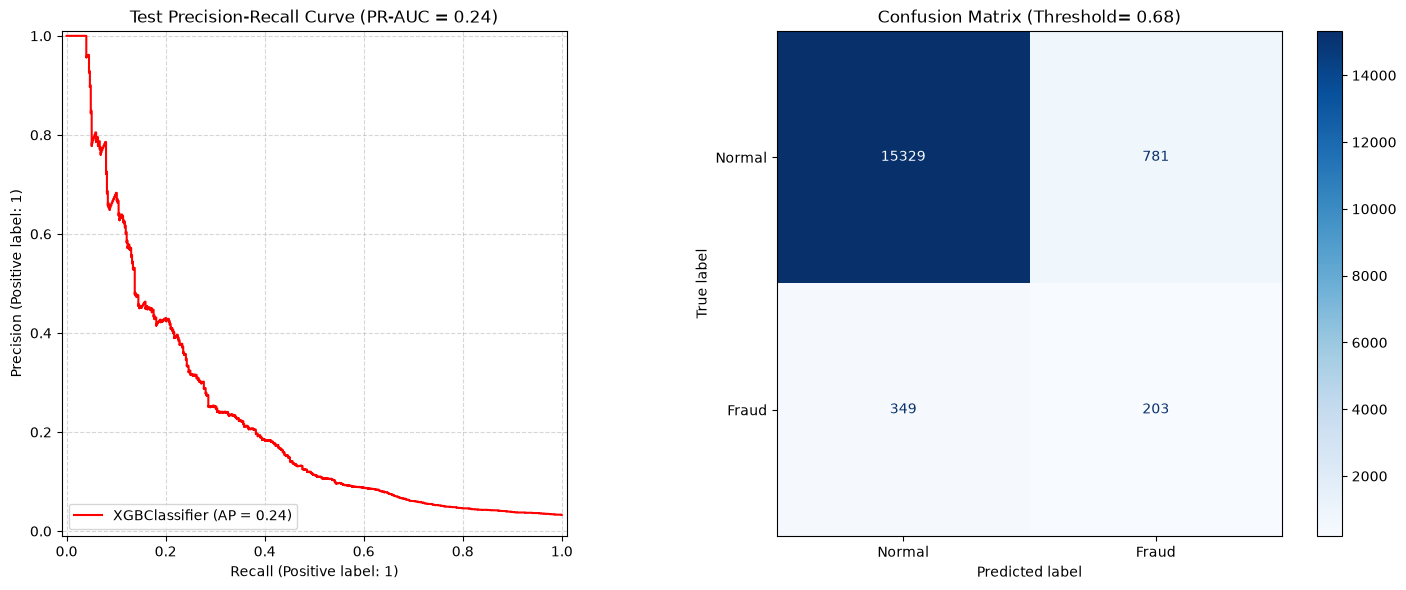

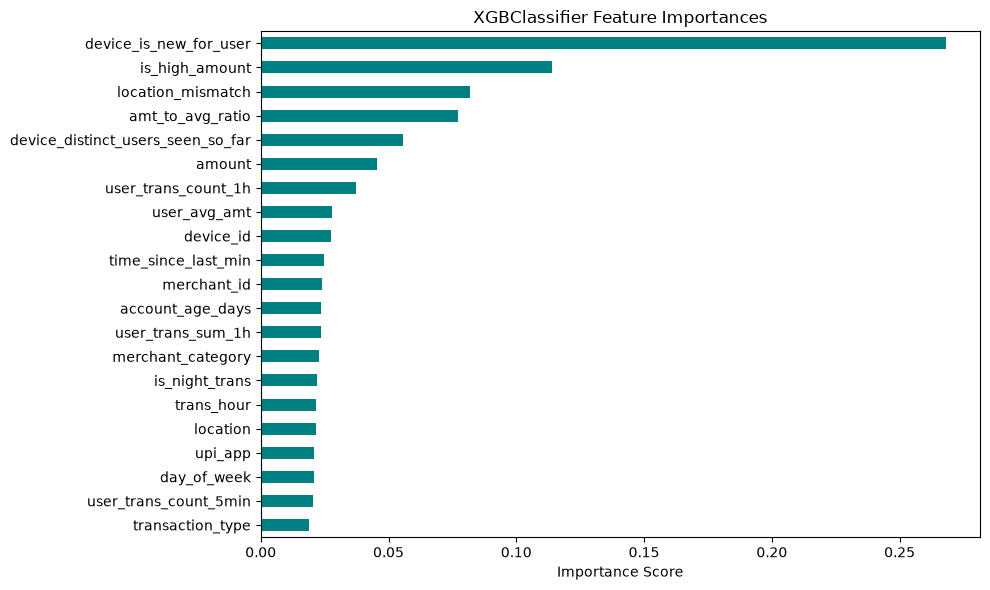

In [21]:
# XGBoost Classifier
neg_count = float((y_train == 0).sum())
pos_count = float((y_train == 1).sum())
cls_weight_ratio = neg_count / pos_count

xgb_model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, 
                          scale_pos_weight=cls_weight_ratio,tree_method='hist', random_state=42)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probs_cv_xgb = cross_val_predict(xgb_model, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
tuned_threshold_xgb = tune_decision_threshold(y_train, y_probs_cv_xgb, beta=1.5)

train_and_evaluate(xgb_model, X_train, y_train, X_test, y_test, tuned_threshold_xgb)


 Test Set PR-AUC (Average Precision): 0.19

 Final Test Set Classification Report (Tuned Threshold)
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     16110
           1       0.12      0.50      0.19       552

    accuracy                           0.86     16662
   macro avg       0.55      0.69      0.56     16662
weighted avg       0.95      0.86      0.90     16662



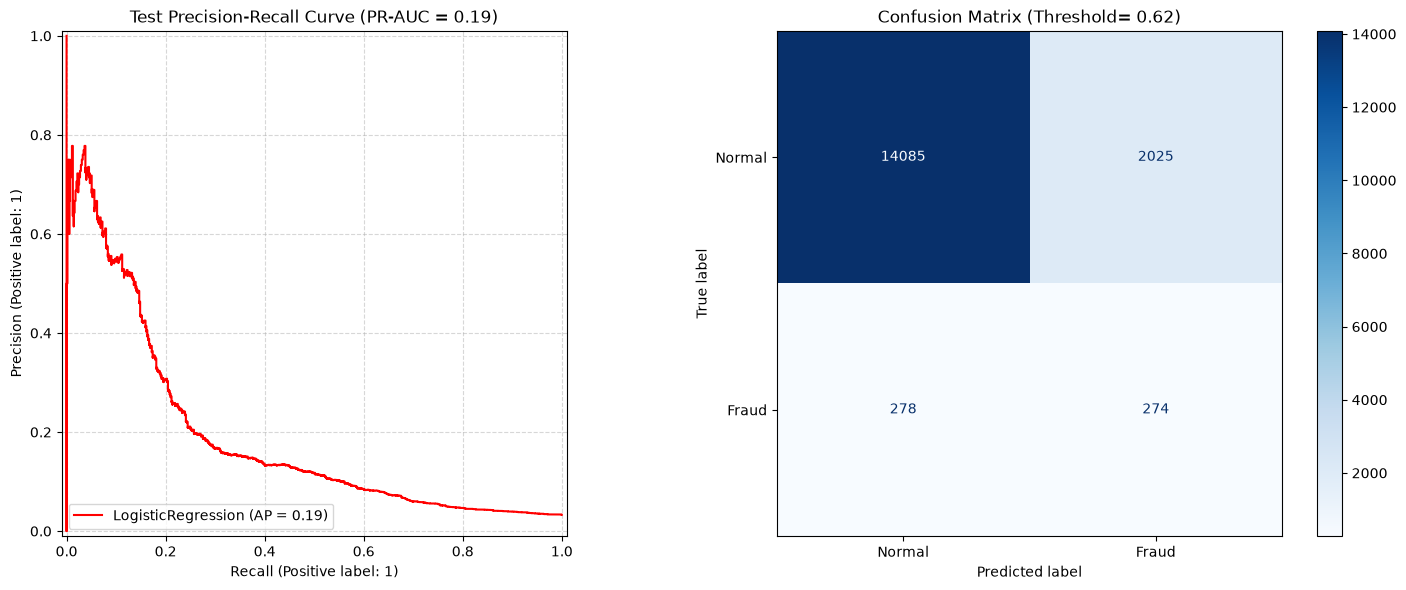

In [22]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=34, class_weight="balanced")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probs_cv_lr = cross_val_predict(lr_model, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
tuned_threshold_lr = tune_decision_threshold(y_train, y_probs_cv_lr, beta=1.5)

train_and_evaluate(lr_model, X_train, y_train, X_test, y_test, tuned_threshold_lr, feature_imp=False)


 Test Set PR-AUC (Average Precision): 0.22

 Final Test Set Classification Report (Tuned Threshold)
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     16110
           1       0.18      0.43      0.26       552

    accuracy                           0.92     16662
   macro avg       0.58      0.68      0.61     16662
weighted avg       0.95      0.92      0.93     16662



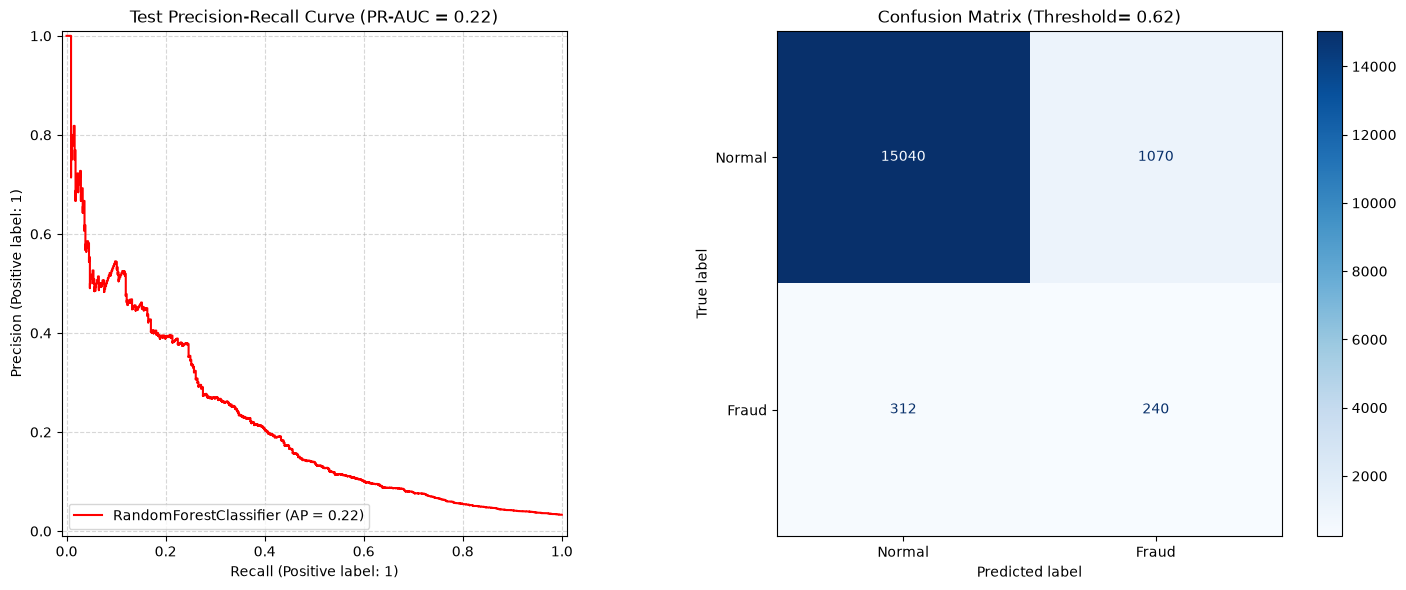

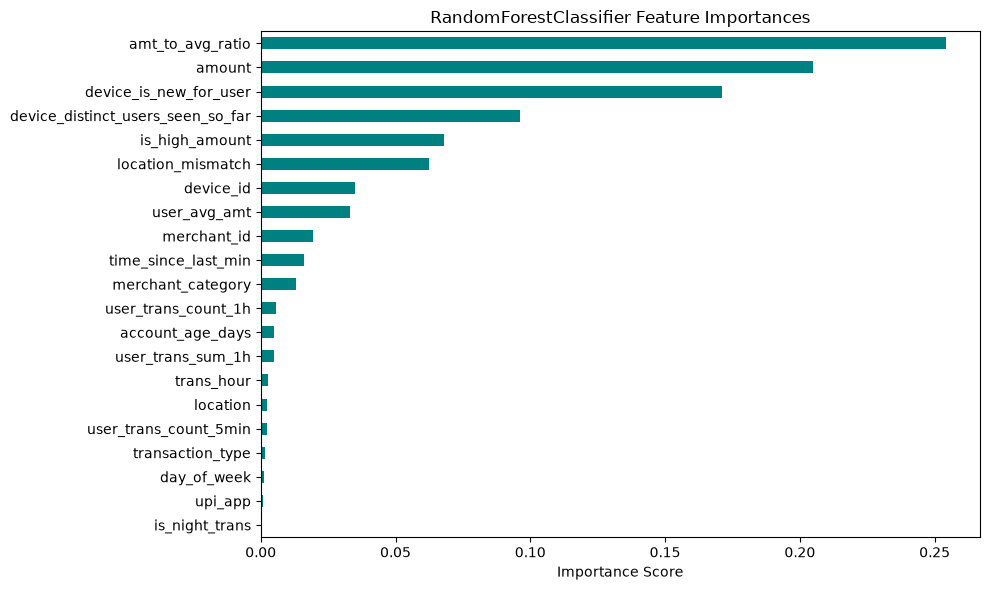

In [23]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight="balanced_subsample", random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probs_cv_rf = cross_val_predict(rf_model, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
tuned_threshold_rf = tune_decision_threshold(y_train, y_probs_cv_rf, beta=1.5)

train_and_evaluate(rf_model, X_train, y_train, X_test, y_test, tuned_threshold_rf, feature_imp=True)

## Visualizing Feature Contribution of XGBoost model using SHAP values

In [24]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

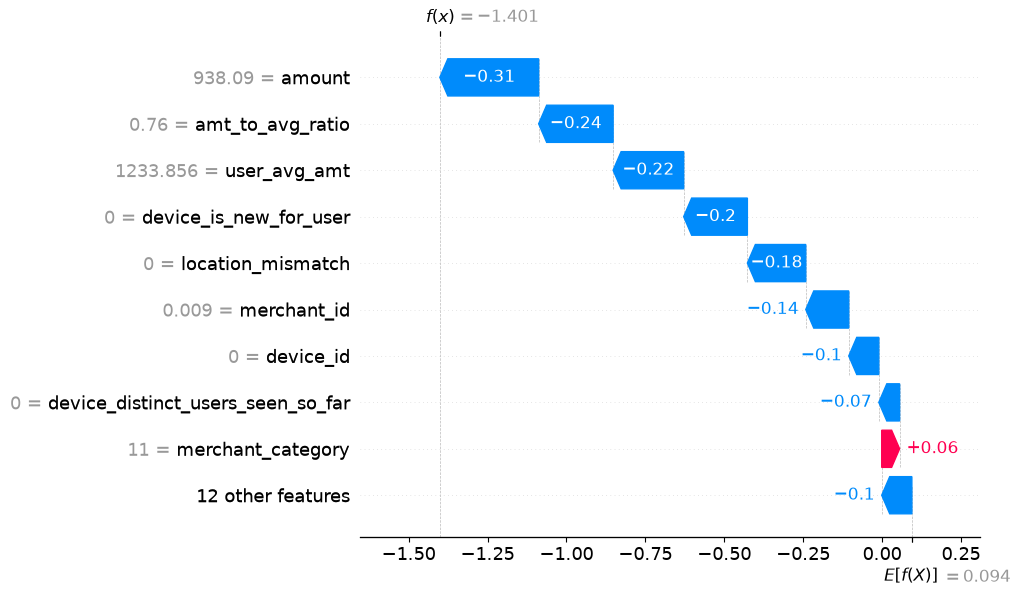

In [25]:
shap.plots.waterfall(shap_values=shap_values[0])

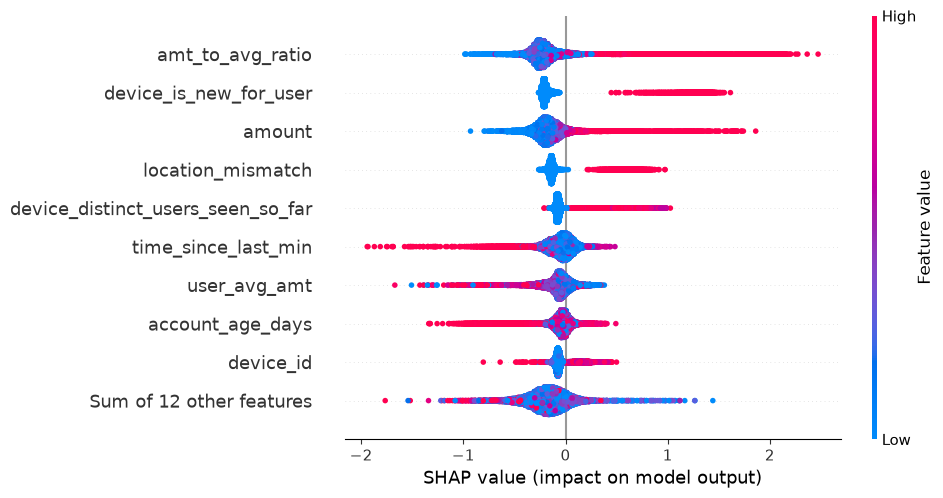

In [26]:
shap.plots.beeswarm(shap_values)

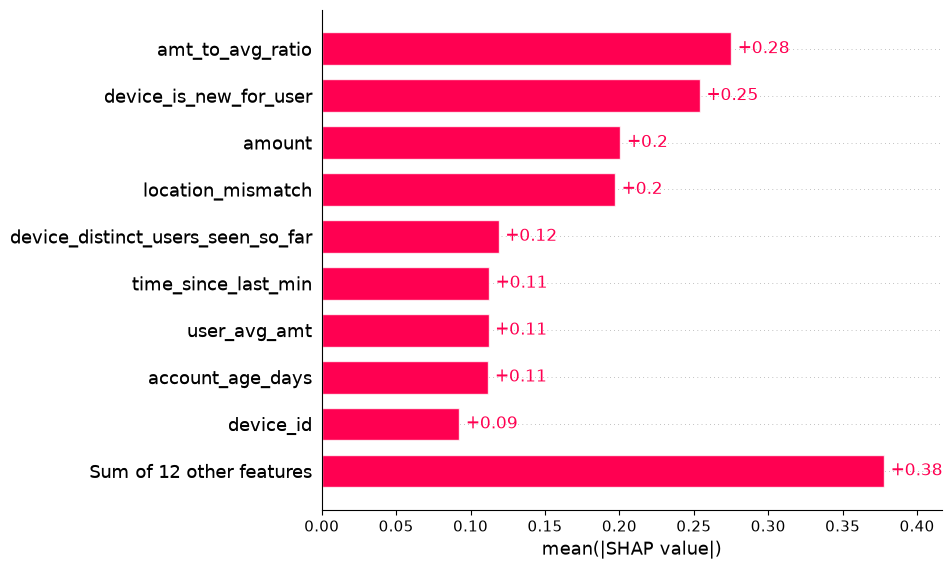

In [27]:
shap.plots.bar(shap_values)

## Model Training to predict Fraud Scenario 

In [28]:
train_df_fs = train_df[(train_df['is_fraud'] != 0) & (train_df['fraud_scenario'] != 'unknown')]
test_df_fs = test_df[(test_df['is_fraud'] != 0) & (test_df['fraud_scenario'] != 'unknown')]

In [29]:
train_df_fs.fraud_scenario.value_counts()

fraud_scenario
unusual_amount       1107
account_takeover      605
suspicious_device     462
velocity_abuse        332
Name: count, dtype: int64

In [30]:
print("Training Data Shape: ", train_df_fs.shape)
print("Test Data Shape: ", test_df_fs.shape)

Training Data Shape:  (2506, 23)
Test Data Shape:  (459, 23)


In [31]:
# separating the features and target for training and test sets
X_train_fs = train_df_fs.drop(columns=['is_fraud','fraud_scenario'])
y_train_fs = train_df_fs[['fraud_scenario']]

X_test_fs = test_df_fs.drop(columns=['is_fraud','fraud_scenario'])
y_test_fs = test_df_fs[['fraud_scenario']]

In [33]:
# encoding the features with the same encoder
X_train_fs[['merchant_id','device_id']] = target_encoder.transform(X_train_fs[['merchant_id','device_id']])
X_test_fs[['merchant_id','device_id']] = target_encoder.transform(X_test_fs[['merchant_id','device_id']])

X_train_fs[cols_to_encode] = encoder.transform(X_train_fs[cols_to_encode])
X_test_fs[cols_to_encode] = encoder.transform(X_test_fs[cols_to_encode])

In [34]:
mapped_fs = {"velocity_abuse": 0, "suspicious_device": 1, "account_takeover": 2, "unusual_amount" : 3}

y_train_fs['fraud_scenario'] = y_train_fs['fraud_scenario'].map(mapped_fs)
y_test_fs['fraud_scenario'] = y_test_fs['fraud_scenario'].map(mapped_fs)

In [35]:
xgb_multi = XGBClassifier(
    objective='multi:softmax', num_class=4, n_estimators=300,
    max_depth=4,           # Keep shallow to prevent overfitting overlaps
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)

xgb_multi.fit(X_train_fs, y_train_fs)
y_preds = xgb_multi.predict(X_test_fs)
print(f"Accuracy Score: {accuracy_score(y_test_fs, y_preds)}")

print("Classification Report")
print(classification_report(y_test_fs, y_preds))

Accuracy Score: 0.5359477124183006
Classification Report
              precision    recall  f1-score   support

           0       0.14      0.11      0.13        53
           1       0.36      0.48      0.41        97
           2       0.46      0.30      0.37       115
           3       0.75      0.81      0.78       194

    accuracy                           0.54       459
   macro avg       0.43      0.43      0.42       459
weighted avg       0.52      0.54      0.52       459



## Anomaly Detector

In [37]:
isolation_for = IsolationForest(contamination=0.03, n_estimators=100, max_samples=256, random_state=23)
isolation_for.fit(X_train)

,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",256
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",23
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=23)


In [39]:
data = pd.DataFrame()
data['anomaly_score'] = isolation_for.decision_function(X_train)
data['anomaly'] = isolation_for.predict(X_train)

In [40]:
data['anomaly'].value_counts()

anomaly
 1    80837
-1     2501
Name: count, dtype: int64

- Out of 83338 data points, 2501 data points are triggered as anomalies. 

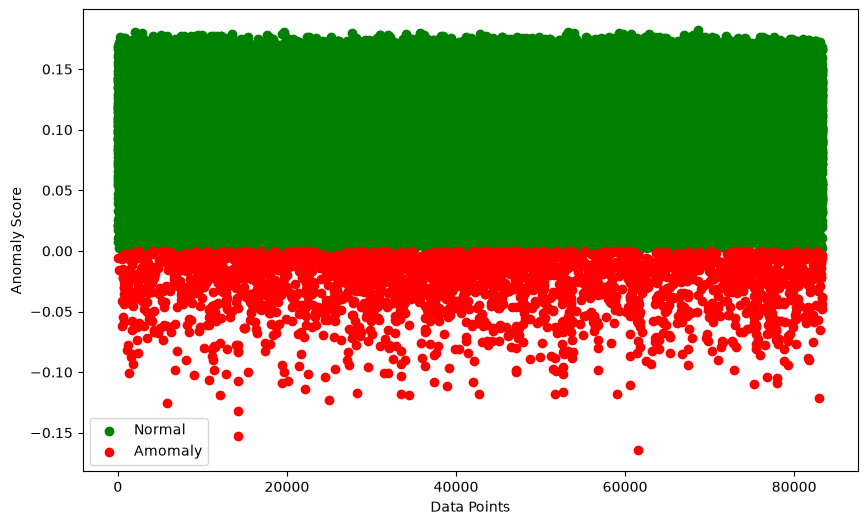

In [41]:
plt.figure(figsize=(10, 6))

normal = data[data.anomaly == 1]
plt.scatter(normal.index, normal['anomaly_score'], label="Normal", color="green")

anomalies = data[data.anomaly == -1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label="Amomaly", color="red")

plt.xlabel("Data Points")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [43]:
### Saving the encoder and models

joblib.dump(encoder, "../models/ordinal_encoder.joblib")
joblib.dump(target_encoder, "../models/target_encoder.joblib")
joblib.dump(xgb_model, "../models/xgb_fraud_model.joblib")
joblib.dump(xgb_multi, "../models/xgb_scenario_model.joblib")
joblib.dump(isolation_for, "../models/iso_forest.joblib")
print("Models Saved!")

Models Saved!
